In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.shape

(1470, 35)

In [3]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


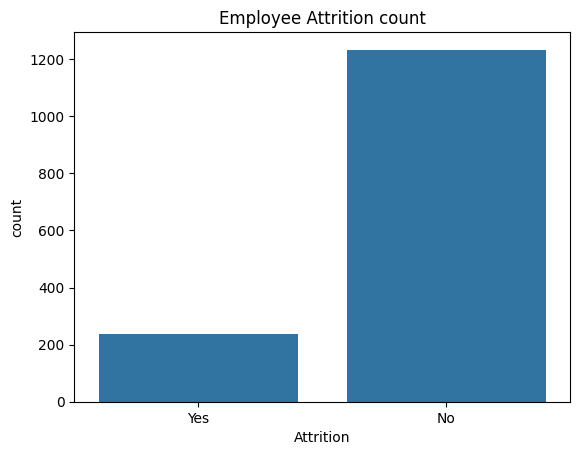

In [5]:
sns.countplot(x="Attrition",data=df)
plt.title("Employee Attrition count")
plt.show()

In [ ]:
precentage_left=(df["Attrition"].value_counts()["Yes"]/len(df))*100
print(f"{precentage_left:.2f}%")

16.12%


In [6]:
df.groupby("Department").size()

,0
Department,
Human Resources,63
Research & Development,961
Sales,446


In [7]:
department_attrition=pd.crosstab(df["Department"],df["Attrition"],normalize="index")*100
department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


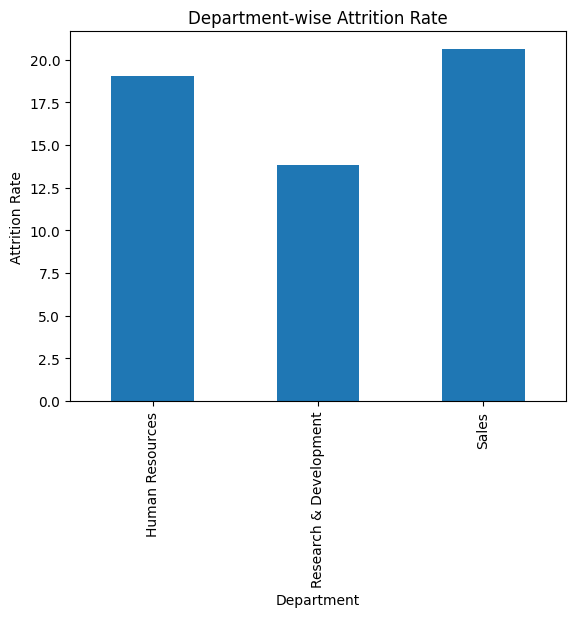

In [8]:
department_attrition["Yes"].plot(kind="bar")
plt.title("Department-wise Attrition Rate")
plt.xlabel("Department")
plt.ylabel("Attrition Rate")
plt.show()

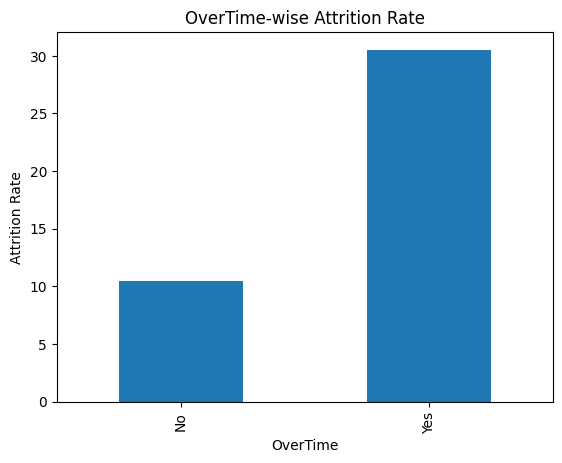

In [9]:
overtime_attrition=pd.crosstab(df["OverTime"],df["Attrition"],normalize="index")*100
overtime_attrition["Yes"].plot(kind="bar")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate")
plt.title("OverTime-wise Attrition Rate")
plt.show()

In [ ]:
df.groupby("Attrition")["MonthlyIncome"].median()

,MonthlyIncome
Attrition,
No,5204.0
Yes,3202.0


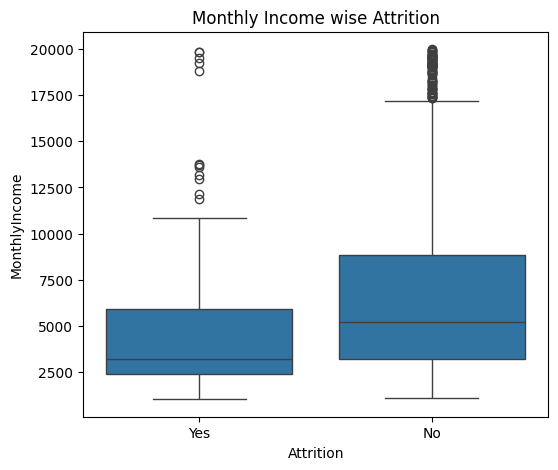

In [10]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)
plt.title("Monthly Income wise Attrition")
plt.show()

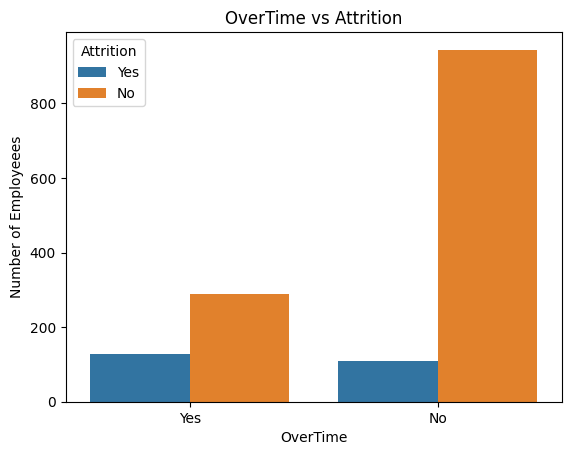

In [11]:
sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df
)
plt.title("OverTime vs Attrition")
plt.ylabel("Number of Employeees")
plt.show()


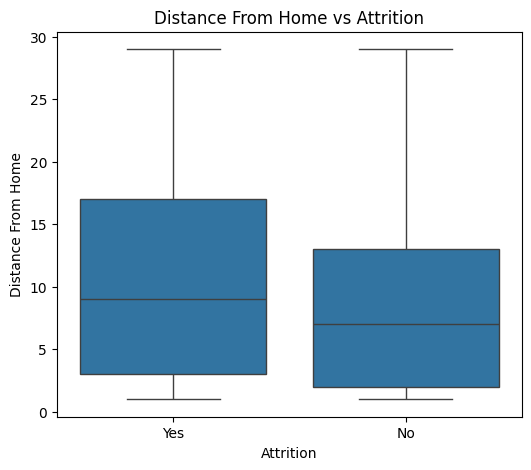

In [12]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x="Attrition",
    y="DistanceFromHome",
    data=df
)
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")
plt.title("Distance From Home vs Attrition")
plt.show()

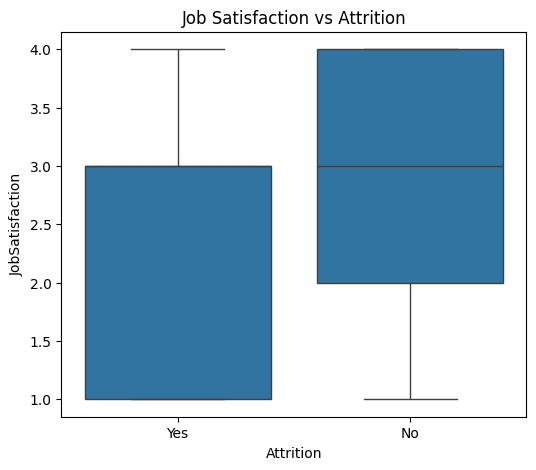

In [13]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x="Attrition",
    y="JobSatisfaction",
    data=df
)
plt.title("Job Satisfaction vs Attrition")
plt.show()

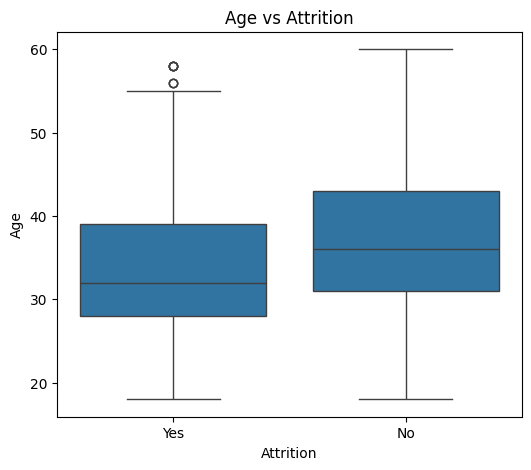

In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x="Attrition",
    y="Age",
    data=df
)
plt.title("Age vs Attrition")
plt.show()

In [15]:

df["Attrition"].unique()
df_corr=df.copy()
df_corr["Attrition"]=df_corr["Attrition"].map({
    "Yes":1,
    "No":0
})
df_corr["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [16]:
corr_mat=df_corr.corr(numeric_only=True)
corr_mat

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,-0.056652,0.077924,-0.031373,NaN,-0.010577,-0.103369,-0.006846,-0.130016,...,-0.045872,NaN,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
DailyRate,0.010661,-0.056652,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,0.077924,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.010577,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,-0.103369,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,-0.006846,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,-0.130016,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976


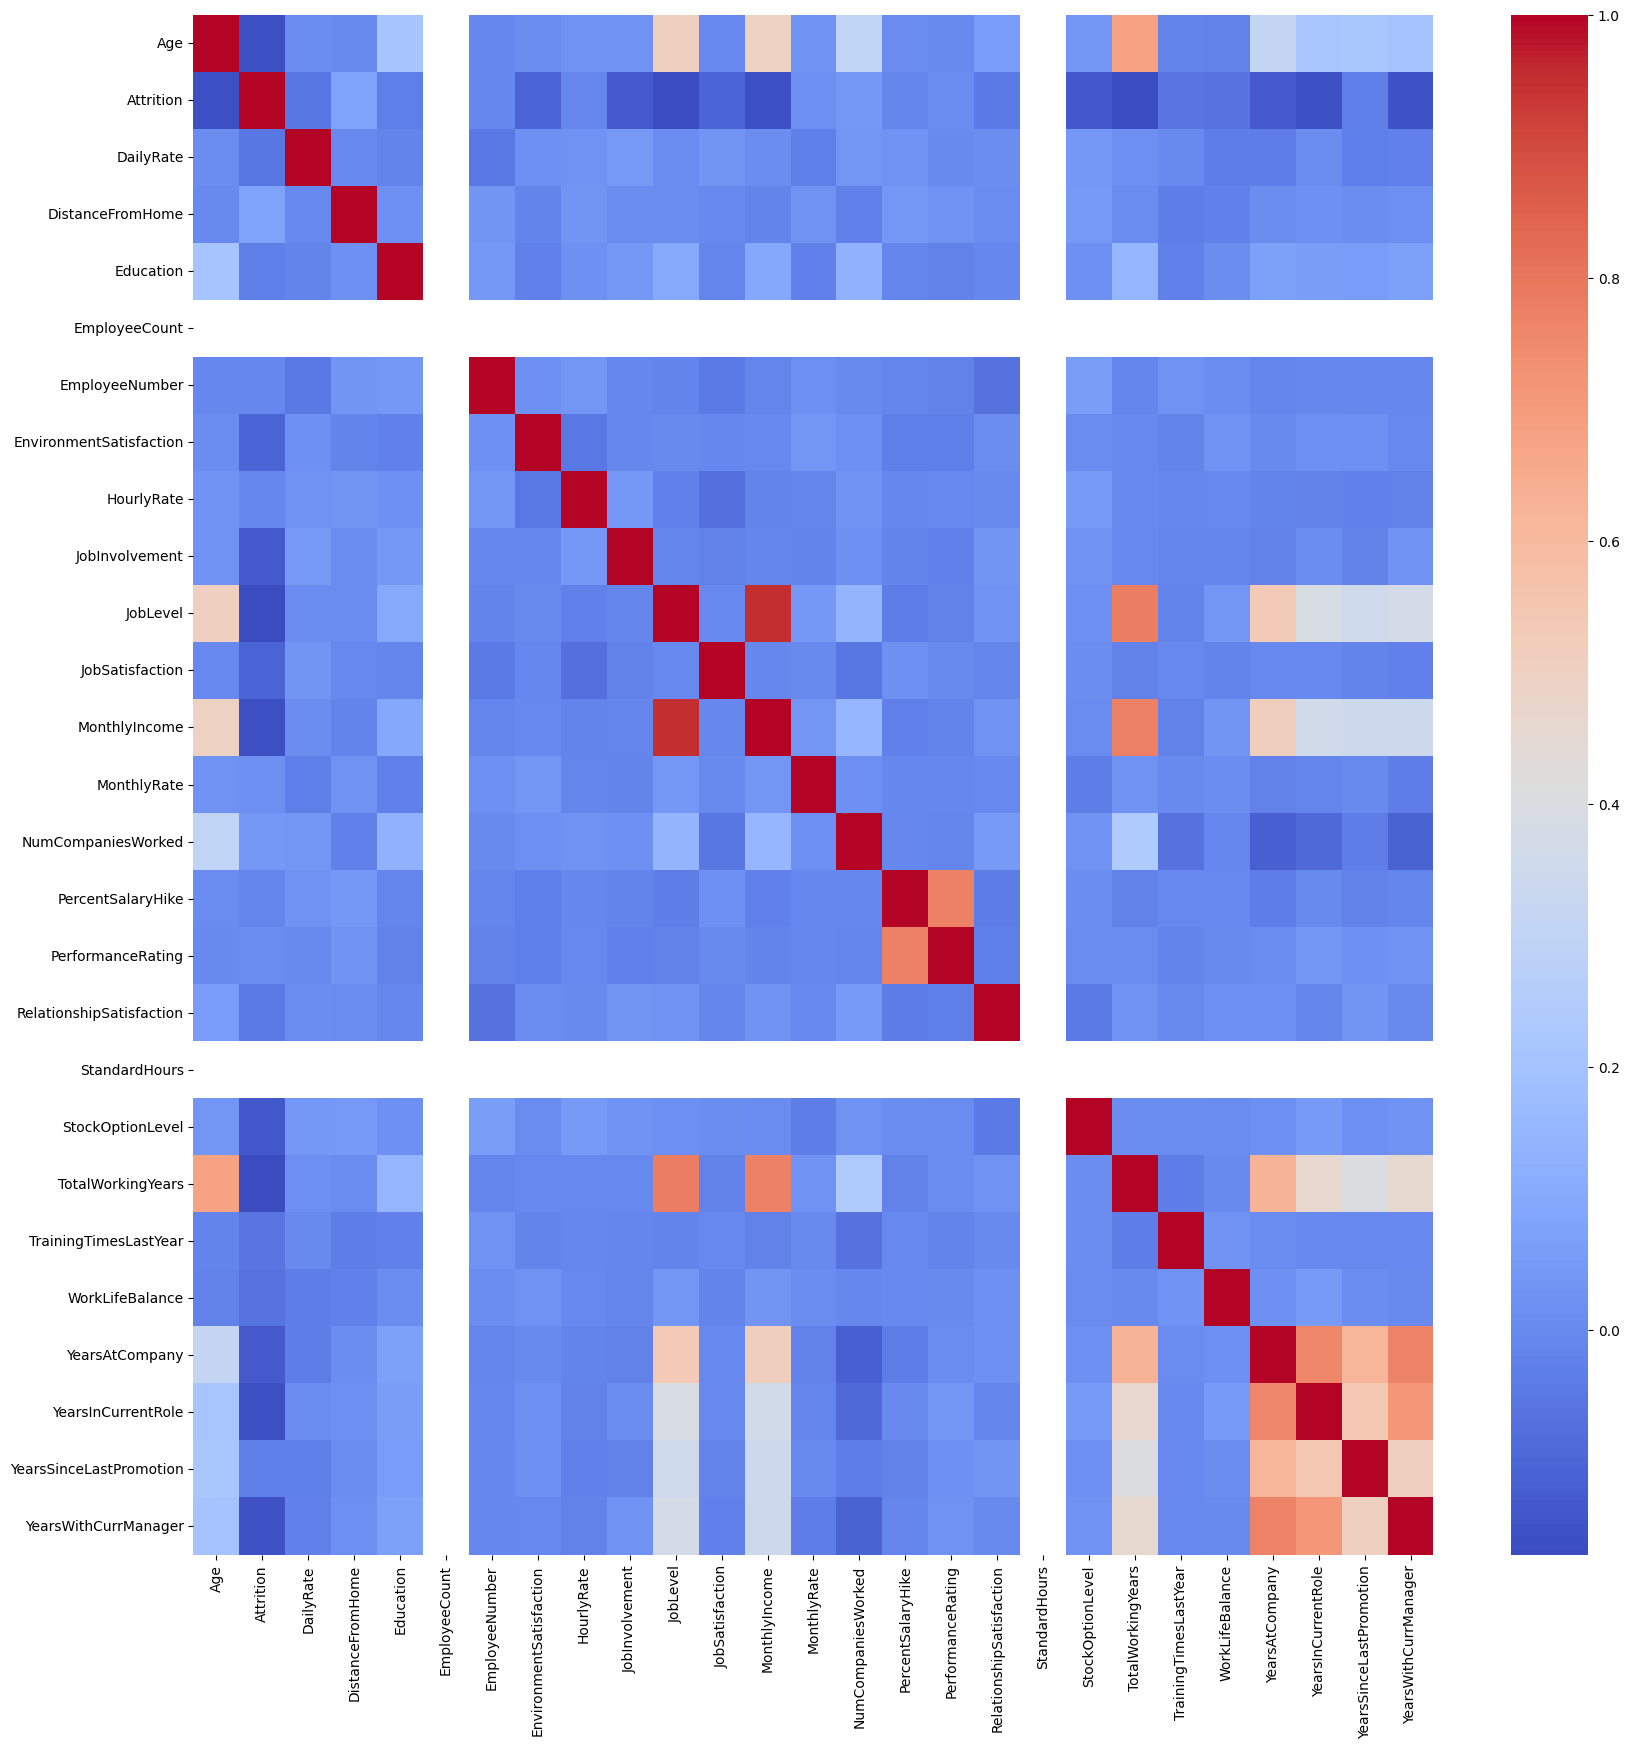

In [17]:
plt.figure(figsize=(20,20))
sns.heatmap(corr_mat,cmap="coolwarm")
plt.show()

In [18]:
df_ml=df.copy()
df_ml=df_ml.drop(columns=["EmployeeCount","StandardHours","EmployeeNumber"])
df_ml.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [19]:
df_encoded=pd.get_dummies(df_ml,drop_first=True)
df_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [20]:
x=df_encoded.drop("Attrition_Yes",axis=1)
y=df_encoded["Attrition_Yes"]
print(x.shape)
print(y.shape)

(1470, 44)
(1470,)


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1176, 44)
(1176,)
(294, 44)
(294,)


In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_prd=model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_prd)
print(cm)

[[253   2]
 [ 38   1]]


In [24]:
from sklearn.metrics import classification_report
l_r=classification_report(y_test,y_prd)
print(l_r)


              precision    recall  f1-score   support

       False       0.87      0.99      0.93       255
        True       0.33      0.03      0.05        39

    accuracy                           0.86       294
   macro avg       0.60      0.51      0.49       294
weighted avg       0.80      0.86      0.81       294



In [25]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
y_prd_rf=rf_model.predict(x_test)

In [26]:
from sklearn.metrics import classification_report
r_c=classification_report(y_test,y_prd_rf)
print(r_c)


              precision    recall  f1-score   support

       False       0.88      1.00      0.93       255
        True       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [31]:
imp=rf_model.feature_importances_
f_imp=pd.DataFrame({
    "feature":x_train.columns,
    "importance":imp
})
print(f_imp)

                              feature  importance
0                                 Age    0.056085
1                           DailyRate    0.051504
2                    DistanceFromHome    0.042809
3                           Education    0.018387
4             EnvironmentSatisfaction    0.024528
5                          HourlyRate    0.041754
6                      JobInvolvement    0.021021
7                            JobLevel    0.024644
8                     JobSatisfaction    0.027273
9                       MonthlyIncome    0.079447
10                        MonthlyRate    0.048895
11                 NumCompaniesWorked    0.037947
12                  PercentSalaryHike    0.035786
13                  PerformanceRating    0.005860
14           RelationshipSatisfaction    0.022190
15                   StockOptionLevel    0.035863
16                  TotalWorkingYears    0.048578
17              TrainingTimesLastYear    0.023972
18                    WorkLifeBalance    0.021916


In [34]:
f_imp=f_imp.sort_values(
    by="importance",
    ascending=False
)
print(f_imp.head(10))

               feature  importance
9        MonthlyIncome    0.079447
43        OverTime_Yes    0.058897
0                  Age    0.056085
1            DailyRate    0.051504
10         MonthlyRate    0.048895
16   TotalWorkingYears    0.048578
2     DistanceFromHome    0.042809
5           HourlyRate    0.041754
19      YearsAtCompany    0.041551
11  NumCompaniesWorked    0.037947


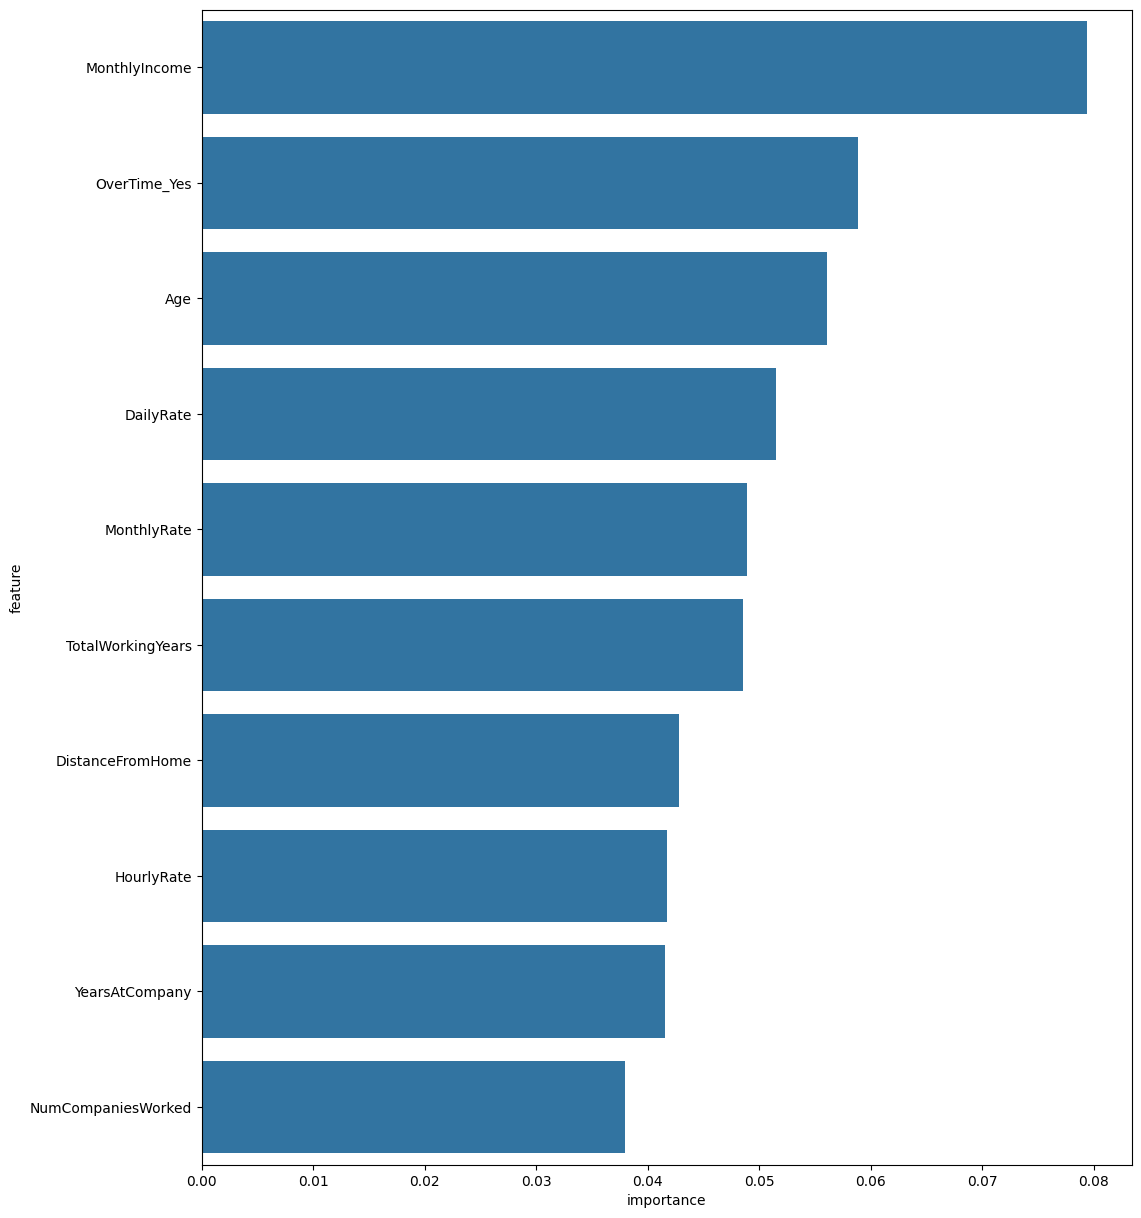

In [40]:
plt.figure(figsize=(12,15))
sns.barplot(
    x="importance",
    y="feature",
    data=f_imp.head(10)
)
plt.show()